In [27]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os

In [28]:
# Load privately owned public spaces and format the data
spaces = pd.read_csv("Privately_Owned_Public_Spaces__POPS__20250310.csv")
spaces = spaces.dropna(subset=["Latitude", "Longitude", "Year_Completed"])
spaces["ZIP Code"] = spaces['Building_Address_With_Zip_Code'].str.split().str[-1]
# remove 0 values
spaces = spaces[spaces["Year_Completed"] != 0]

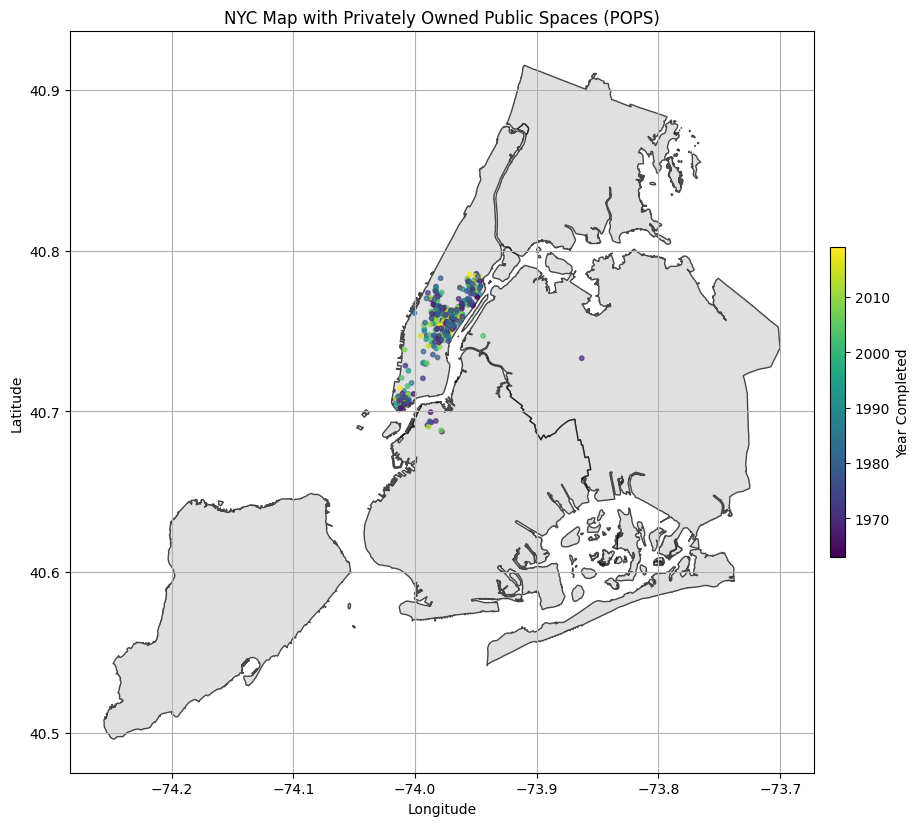

In [29]:
# Create GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(spaces["Longitude"], spaces["Latitude"]), 
    crs="EPSG:4326"
)

# Read NYC map
nyc_map = gpd.read_file(get_path("nybb")).to_crs(epsg=4326)

# Define colormap and normalization
cmap = plt.cm.viridis  # Use the viridis colormap
norm = mcolors.Normalize(vmin=spaces["Year_Completed"].min(), vmax=spaces["Year_Completed"].max())

# Plot the map
fig, ax = plt.subplots(figsize=(10, 10))
nyc_map.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.7)

# Plot points with assigned colors
gdf_points.plot(ax=ax, cmap=cmap, markersize=10, alpha=0.7)

# Create a colorbar (sidebar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Year Completed")

# Titles and labels
plt.title("NYC Map with Privately Owned Public Spaces (POPS)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.show()

In [30]:
# Load all NYC SAFMR data
input_files_path = os.path.join("safmr_filtered", "*.csv")
input_files = glob.glob(input_files_path)

yearly_zip_code_rents = {}
rent_standard = 'SAFMR 2BR'
br1_rent_standard = 'SAFMR 1BR'

for file in input_files:
    df = pd.read_csv(file)
    _filtered = df[['ZIP Code', rent_standard, br1_rent_standard]]

    df['ZIP Code'] = df['ZIP Code'].astype(str)
    df[rent_standard] = (
        df[rent_standard]
        .replace({'\$': '', ',': ''}, regex=True)
        .astype(float)
    )
    df[br1_rent_standard] = (
        df[br1_rent_standard]
        .replace({'\$': '', ',': ''}, regex=True)
        .astype(float)
    )
        
    zip_values = dict(zip(df['ZIP Code'], df[rent_standard]))

    year = os.path.basename(file).split('.')[0][2:]  # Extract year from filename
    yearly_zip_code_rents[year] = zip_values

<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Trevor Semeraro\AppData\Local\Temp\ipykernel_1724\2975008225.py:16: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)
C:\Users\Trevor Semeraro\AppData\Local\Temp\ipykernel_1724\2975008225.py:21: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)


In [31]:
yearly_zip_code_rents.keys()
zip_values = yearly_zip_code_rents['2025']
zip_values

{'12007': 1510.0,
 '12008': 1500.0,
 '12009': 1520.0,
 '12010': 1240.0,
 '12018': 1650.0,
 '12019': 1530.0,
 '12020': 1840.0,
 '12022': 1530.0,
 '12023': 1280.0,
 '12024': 1430.0,
 '12025': 1240.0,
 '12027': 2180.0,
 '12028': 1330.0,
 '12031': 1240.0,
 '12033': 1540.0,
 '12035': 1290.0,
 '12036': 1240.0,
 '12040': 1470.0,
 '12041': 1390.0,
 '12043': 1240.0,
 '12045': 1630.0,
 '12046': 1350.0,
 '12047': 1510.0,
 '12052': 1580.0,
 '12053': 1240.0,
 '12054': 1830.0,
 '12055': 1510.0,
 '12056': 1490.0,
 '12057': 1330.0,
 '12059': 1270.0,
 '12061': 1910.0,
 '12062': 1340.0,
 '12063': 1550.0,
 '12064': 1290.0,
 '12065': 1580.0,
 '12066': 1500.0,
 '12067': 1240.0,
 '12071': 1240.0,
 '12073': 1240.0,
 '12074': 1570.0,
 '12076': 1320.0,
 '12077': 1690.0,
 '12082': 1580.0,
 '12083': 1240.0,
 '12084': 1810.0,
 '12085': 1240.0,
 '12086': 1240.0,
 '12087': 1260.0,
 '12089': 1440.0,
 '12090': 1240.0,
 '12092': 1280.0,
 '12093': 1240.0,
 '12094': 1350.0,
 '12107': 1510.0,
 '12110': 1750.0,
 '12118': 

In [32]:
gdf = gpd.read_file('zipcode/geo_export_b459f634-6bcb-46d7-ade3-b0ef95b76ebc.shp')
gdf['label'] = gdf['label'].str.split(',').str[0]

In [33]:
gdf['rent'] = gdf['label'].map(zip_values)
gdf = gdf.dropna(subset=['rent'])
gdf['label'] = gdf['label'].astype(int)
gdf['label']

0      10001
1      10002
2      10003
3      10026
4      10004
       ...  
172    11433
173    11434
174    11435
175    11694
176    11697
Name: label, Length: 177, dtype: int32

In [34]:
manhattan_shapes = gdf[gdf['label'] < 10282]
manhattan_shapes['label'] = manhattan_shapes['label'].astype(str)
manhattan_shapes

c:\Users\Trevor Semeraro\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,modzcta,label,zcta,pop_est,geometry,rent
0,10001,10001,"10001, 10119, 10199",23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",3560.0
1,10002,10002,10002,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",2480.0
2,10003,10003,10003,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",3870.0
3,10026,10026,10026,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",2510.0
4,10004,10004,10004,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",3720.0
5,10005,10005,"10005, 10271",8831.0,"POLYGON ((-74.00783 40.70309, -74.00786 40.703...",3870.0
6,10006,10006,10006,3454.0,"POLYGON ((-74.01251 40.70677, -74.01325 40.705...",3870.0
7,10007,10007,"10007, 10278, 10279",7023.0,"POLYGON ((-74.00998 40.70981, -74.01123 40.710...",3190.0
8,10009,10009,10009,57925.0,"POLYGON ((-73.98864 40.72293, -73.98859 40.723...",2750.0
9,10010,10010,10010,33730.0,"POLYGON ((-73.97979 40.73496, -73.97988 40.735...",3180.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


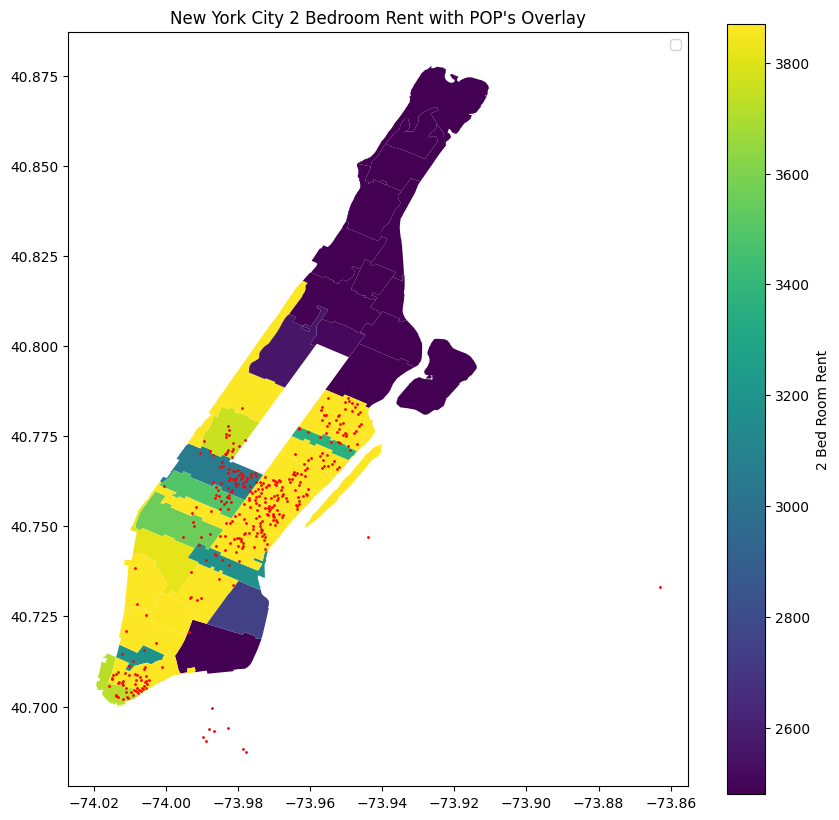

In [35]:
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=manhattan_shapes['rent'].min(), vmax=manhattan_shapes['rent'].max())

fig, ax = plt.subplots(figsize=(10, 10))

manhattan_shapes.plot(ax=ax, column='rent', cmap=cmap, legend=True, legend_kwds={'label': "2 Bed Room Rent", 'orientation': "vertical"})

ax.set_title("New York City 2 Bedroom Rent with POP's Overlay")
ax.legend()

geometry = [Point(lon, lat) for lon, lat in zip(spaces['Longitude'], spaces['Latitude'])]
lat_lon_gdf = gpd.GeoDataFrame(spaces, geometry=geometry)

# Plot lat/long data points
lat_lon_gdf.plot(ax=ax, color='red', markersize=1, label="Lat/Lon Points")


plt.show()

In [36]:
len(zip_values.keys())

1540

In [37]:
pop_zip_codes, counts = np.unique(spaces['ZIP Code'], return_counts=True)
zip_code_counts = dict(zip(pop_zip_codes, counts))
print(zip_code_counts)

{'10001': 4, '10002': 1, '10003': 6, '10004': 12, '10005': 14, '10006': 8, '10007': 4, '10010': 5, '10011': 1, '10013': 3, '10014': 2, '10016': 34, '10017': 30, '10018': 4, '10019': 36, '10020': 1, '10021': 15, '10022': 47, '10023': 17, '10024': 1, '10028': 14, '10036': 16, '10038': 12, '10041': 1, '10055': 1, '10065': 12, '10075': 8, '10105': 1, '10106': 1, '10119': 1, '10121': 1, '10128': 22, '10153': 1, '10154': 1, '10155': 1, '10167': 1, '10171': 1, '10178': 1, '10179': 1, '11101': 1, '11201': 6, '11217': 2, '11374': 1}


In [38]:
# section the data with those that do not have pops, and those that do
for year, zip_code_rents in yearly_zip_code_rents.items():
    for zip_code, value in zip_values.items():
        if zip_code not in zip_code_counts:
            zip_code_counts[zip_code] = 0

In [39]:
# get the average rent increase for zip codes that do have POPS, and those that do not
zip_code_df = pd.DataFrame(list(zip_code_counts.items()), columns=['ZIP Code', 'Count'])

# Compute rent increase for each ZIP code over the years
rent_increases = {}

for year, zip_code_rents in yearly_zip_code_rents.items():
    for zip_code, rent in zip_code_rents.items():
        if zip_code not in rent_increases:
            rent_increases[zip_code] = []
        rent_increases[zip_code].append(rent)

# Calculate the average rent increase for each ZIP code
avg_rent_increases = {}
for zip_code, rents in rent_increases.items():
    # get percent increase from the first year to the last year
    avg_rent_increases[zip_code] = {
        "rent_increase": rents[-1] - rents[0],
        "rent_pct_change": (rents[-1] - rents[0]) / rents[0] * 100,
        "rent": rents[-1],
        "pops_count": zip_code_counts.get(zip_code, 0)
    }

# Convert dictionary to DataFrame
avg_rent_increase_df = pd.DataFrame.from_dict(avg_rent_increases, orient='index')

# Reset index and rename columns
avg_rent_increase_df.reset_index(inplace=True)
avg_rent_increase_df.rename(columns={'index': 'ZIP Code'}, inplace=True)

display(avg_rent_increase_df)

,ZIP Code,rent_increase,rent_pct_change,rent,pops_count
0,12007,380.0,33.628319,1510.0,0
1,12008,460.0,44.230769,1500.0,0
2,12009,310.0,25.619835,1520.0,0
3,12010,310.0,33.333333,1240.0,0
4,12018,330.0,25.000000,1650.0,0
...,...,...,...,...,...
1540,13505,210.0,21.649485,1180.0,0
1541,12434,50.0,4.201681,1240.0,0
1542,14260,320.0,26.890756,1510.0,0
1543,13433,0.0,0.000000,1010.0,0


In [40]:
non_pops = avg_rent_increase_df[avg_rent_increase_df['pops_count'] == 0]
pops = avg_rent_increase_df[avg_rent_increase_df['pops_count'] != 0]
many_pops = avg_rent_increase_df[avg_rent_increase_df['pops_count'] > 5]

In [41]:
many_pops.to_csv('./output/many_pops.csv', index=False)

In [42]:
print("Non POPS:", non_pops['rent'].mean(), non_pops['rent_increase'].mean(), non_pops['rent_pct_change'].mean())
print("POPS:", pops['rent'].mean(), pops['rent_increase'].mean(), pops['rent_pct_change'].mean())
print("Many POPS:", many_pops['rent'].mean(), many_pops['rent_increase'].mean(), many_pops['rent_pct_change'].mean())

Non POPS: 1913.249001331558 533.2956058588549 39.98139559205079
POPS: 3495.813953488372 915.5813953488372 36.20101380843153
Many POPS: 3754.705882352941 1009.4117647058823 36.75010514931202


In [43]:
racial_2000 = pd.read_csv(os.path.join('racial_data', '2000data.csv'))
racial_2010 = pd.read_csv(os.path.join('racial_data', '2010data.csv'))
racial_2020 = pd.read_csv(os.path.join('racial_data', '2020data.csv'))

racial_2000["White alone"] = racial_2000["White alone"].str.replace(",", "").astype(float)
racial_2000["Black or African American alone"] = racial_2000["Black or African American alone"].str.replace(",", "").astype(float)
racial_2000["Asian alone"] = racial_2000["Asian alone"].str.replace(",", "").astype(float)
racial_2000["Total:"] = racial_2000["Total:"].str.replace(",", "").astype(float)
racial_2000["Population of one race:"] = racial_2000["Population of one race:"].str.replace(",", "").astype(float)

In [44]:
racial_2000["ZIP Code"] = racial_2000["NAME"].str.split(" ").str[-1]
racial_2000["perc_white"] = racial_2000["White alone"] / racial_2000["Population of one race:"]
racial_2000["perc_black"] = racial_2000["Black or African American alone"] / racial_2000["Population of one race:"]
racial_2000["perc_asian"] = racial_2000["Asian alone"] / racial_2000["Population of one race:"]

racial_2010["ZIP Code"] = racial_2010["NAME"].str.split(" ").str[-1]
racial_2010["perc_white"] = racial_2010["P008003"] / racial_2010["P008002"]
racial_2010["perc_black"] = racial_2010["P008004"] / racial_2010["P008002"]
racial_2010["perc_asian"] = racial_2010["P008006"] / racial_2010["P008002"]

racial_2020["ZIP Code"] = racial_2020["NAME"].str.split(" ").str[-1]
racial_2020["perc_white"] = racial_2020["P8_003N"] / racial_2020["P8_002N"]
racial_2020["perc_black"] = racial_2020["P8_004N"] / racial_2020["P8_002N"]
racial_2020["perc_asian"] = racial_2020["P8_006N"] / racial_2020["P8_002N"]

In [45]:
percent_change = pd.DataFrame()
percent_change['ZIP Code'] = racial_2000['ZIP Code']

percent_change['2020_perc_white'] = racial_2020['perc_white']
percent_change['2000_perc_white'] = racial_2000['perc_white']

percent_change['change_perc_white'] = racial_2020['perc_white'] - racial_2000['perc_white']
percent_change['change_perc_black'] = racial_2020['perc_black'] - racial_2000['perc_black']
percent_change['change_perc_asian'] = racial_2020['perc_asian'] - racial_2000['perc_asian']

percent_change

,ZIP Code,2020_perc_white,2000_perc_white,change_perc_white,change_perc_black,change_perc_asian
0,10001,0.585334,0.661878,-0.076544,0.022036,0.055519
1,10002,0.306321,0.271230,0.035091,0.031684,-0.063772
2,10003,0.755346,0.800081,-0.044735,-0.000330,0.031786
3,10004,0.666405,0.775107,-0.108702,-0.008020,0.116212
4,10005,0.721582,0.694282,0.027299,0.010539,-0.033379
...,...,...,...,...,...,...
61,10271,0.700000,NaN,NaN,NaN,NaN
62,10278,NaN,NaN,NaN,NaN,NaN
63,10279,0.224138,NaN,NaN,NaN,NaN
64,10280,NaN,0.760661,NaN,NaN,NaN


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


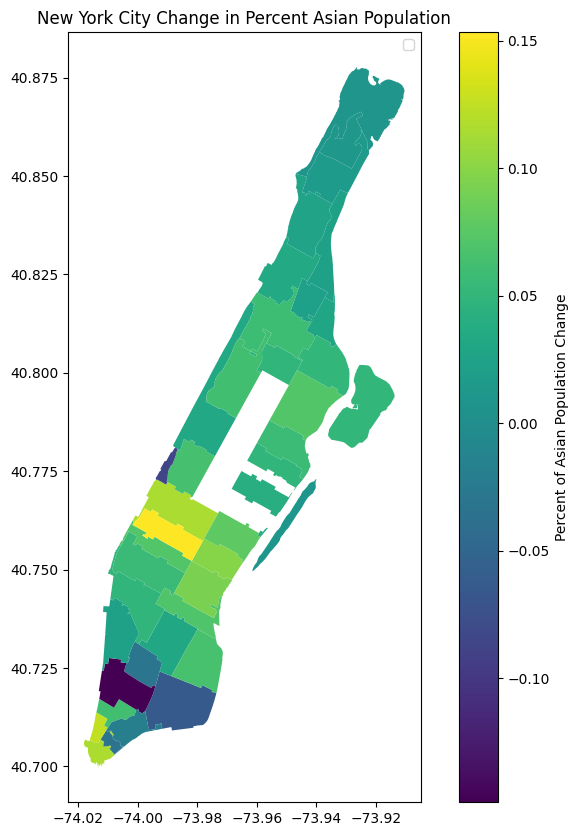

In [46]:
racial_group = 'change_perc_asian'
gdf_with_race_change = manhattan_shapes.merge(percent_change[['ZIP Code', racial_group]], left_on='label', right_on='ZIP Code', how='left')

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf_with_race_change[racial_group].min(), vmax=gdf_with_race_change[racial_group].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf_with_race_change.plot(ax=ax, column=racial_group, cmap=cmap, legend=True, legend_kwds={'label': "Percent of Asian Population Change", 'orientation': "vertical"})

ax.set_title("New York City Change in Percent Asian Population")
ax.legend()

plt.show()

In [47]:
percent_change[percent_change["ZIP Code"] == "10022"]

,ZIP Code,2020_perc_white,2000_perc_white,change_perc_white,change_perc_black,change_perc_asian
19,10022,0.803616,0.911036,-0.10742,0.013575,0.07901


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


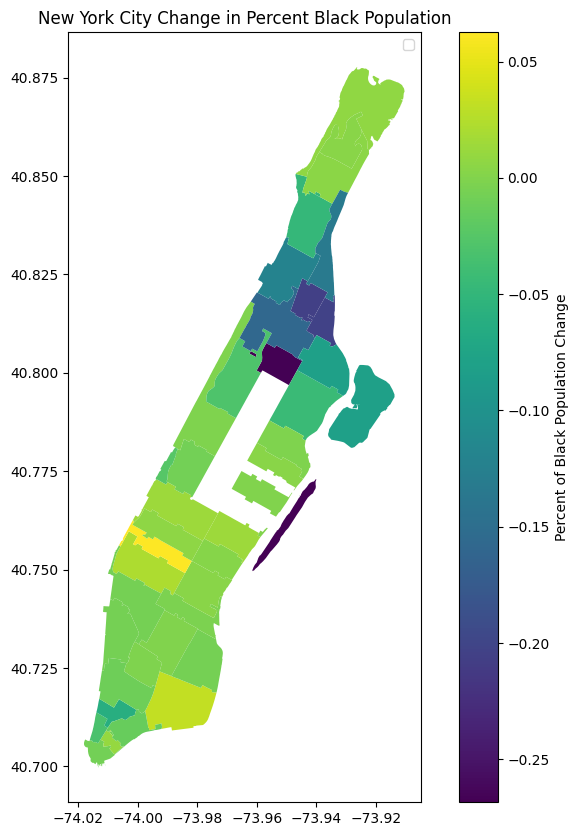

In [48]:
racial_group = 'change_perc_black'
gdf_with_race_change = manhattan_shapes.merge(percent_change[['ZIP Code', racial_group]], left_on='label', right_on='ZIP Code', how='left')

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf_with_race_change[racial_group].min(), vmax=gdf_with_race_change[racial_group].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf_with_race_change.plot(ax=ax, column=racial_group, cmap=cmap, legend=True, legend_kwds={'label': "Percent of Black Population Change", 'orientation': "vertical"})

ax.set_title("New York City Change in Percent Black Population")
ax.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


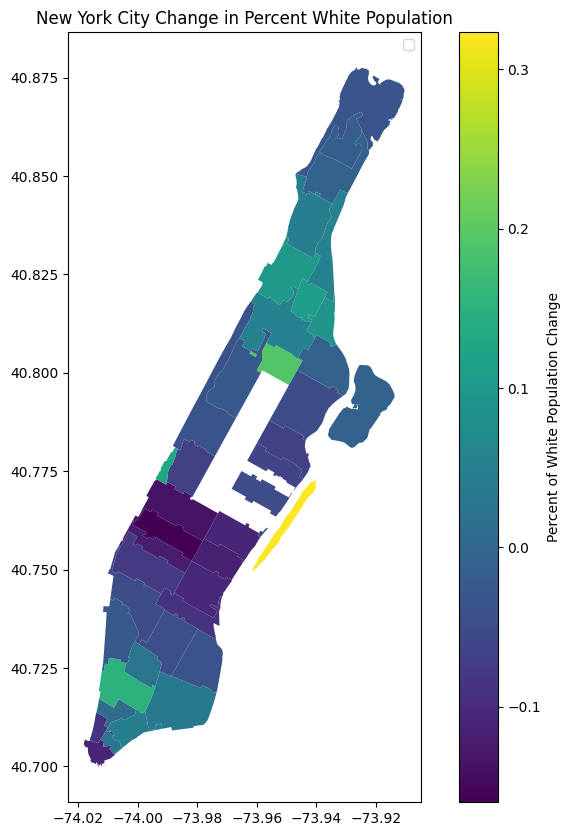

In [49]:
racial_group = 'change_perc_white'
gdf_with_race_change = manhattan_shapes.merge(percent_change[['ZIP Code', racial_group]], left_on='label', right_on='ZIP Code', how='left')

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf_with_race_change[racial_group].min(), vmax=gdf_with_race_change[racial_group].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf_with_race_change.plot(ax=ax, column=racial_group, cmap=cmap, legend=True, legend_kwds={'label': "Percent of White Population Change", 'orientation': "vertical"})

ax.set_title("New York City Change in Percent White Population")
ax.legend()

plt.show()

In [50]:
racial_group = 'perc_white'
gdf_with_race = manhattan_shapes.merge(racial_2020[['ZIP Code', racial_group]], left_on='label', right_on='ZIP Code', how='left')
gdf_with_race

,modzcta,label,zcta,pop_est,geometry,rent,ZIP Code,perc_white
0,10001,10001,"10001, 10119, 10199",23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",3560.0,10001,0.585334
1,10002,10002,10002,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",2480.0,10002,0.306321
2,10003,10003,10003,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",3870.0,10003,0.755346
3,10026,10026,10026,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",2510.0,10026,0.283034
4,10004,10004,10004,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",3720.0,10004,0.666405
5,10005,10005,"10005, 10271",8831.0,"POLYGON ((-74.00783 40.70309, -74.00786 40.703...",3870.0,10005,0.721582
6,10006,10006,10006,3454.0,"POLYGON ((-74.01251 40.70677, -74.01325 40.705...",3870.0,10006,0.714249
7,10007,10007,"10007, 10278, 10279",7023.0,"POLYGON ((-74.00998 40.70981, -74.01123 40.710...",3190.0,10007,0.741226
8,10009,10009,10009,57925.0,"POLYGON ((-73.98864 40.72293, -73.98859 40.723...",2750.0,10009,0.593248
9,10010,10010,10010,33730.0,"POLYGON ((-73.97979 40.73496, -73.97988 40.735...",3180.0,10010,0.712157


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


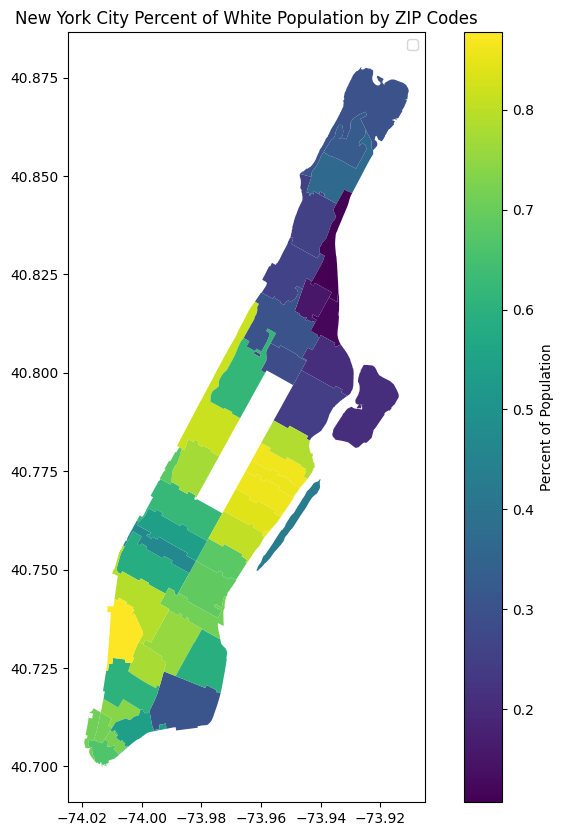

In [51]:
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf_with_race[racial_group].min(), vmax=gdf_with_race[racial_group].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf_with_race.plot(ax=ax, column=racial_group, cmap=cmap, legend=True, legend_kwds={'label': "Percent of Population", 'orientation': "vertical"})

ax.set_title("New York City Percent of White Population by ZIP Codes")
ax.legend()

plt.show()

Zip Code 10019 appears to have roughly 60% white, in 1980 it was roughly White: 91.65%

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


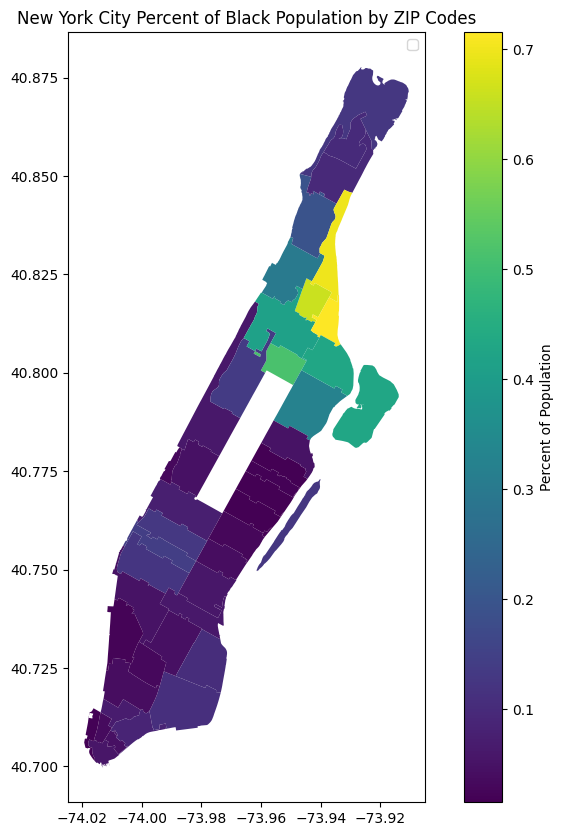

In [52]:
racial_group = 'perc_black'
gdf_with_race = manhattan_shapes.merge(racial_2020[['ZIP Code', racial_group]], left_on='label', right_on='ZIP Code', how='left')

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf_with_race[racial_group].min(), vmax=gdf_with_race[racial_group].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf_with_race.plot(ax=ax, column=racial_group, cmap=cmap, legend=True, legend_kwds={'label': "Percent of Population", 'orientation': "vertical"})

ax.set_title("New York City Percent of Black Population by ZIP Codes")
ax.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


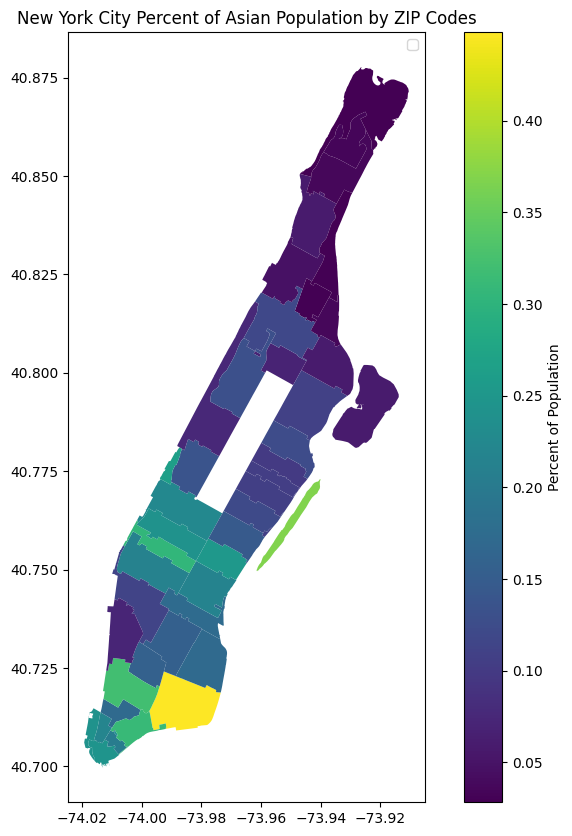

In [54]:
racial_group = 'perc_asian'
gdf_with_race = manhattan_shapes.merge(racial_2020[['ZIP Code', racial_group]], left_on='label', right_on='ZIP Code', how='left')

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf_with_race[racial_group].min(), vmax=gdf_with_race[racial_group].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf_with_race.plot(ax=ax, column=racial_group, cmap=cmap, legend=True, legend_kwds={'label': "Percent of Population", 'orientation': "vertical"})

ax.set_title("New York City Percent of Asian Population by ZIP Codes")
ax.legend()


plt.show()

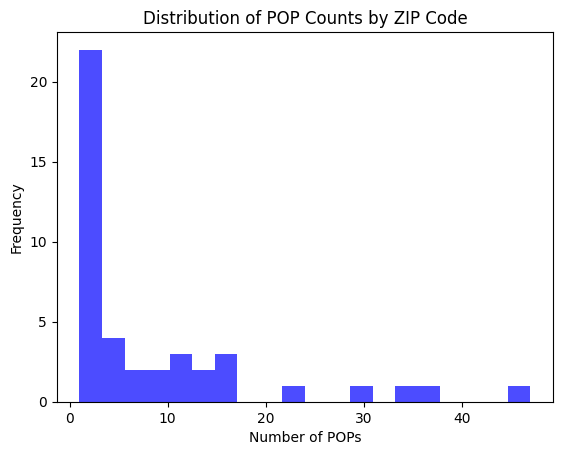

In [ ]:
values, zip_code_pop_counts = np.unique(spaces['ZIP Code'], return_counts=True)

pop_values, pop_counts = np.unique(zip_code_pop_counts, return_counts=True)
plt.hist(zip_code_pop_counts, bins=20, color='blue', alpha=0.7, label='POP Counts')
plt.xlabel('Number of POPs')
plt.ylabel('Frequency')
plt.title('Distribution of POP Counts by ZIP Code')
plt.show()